# 🌾 Crop Yield Prediction — Neural Network

**Goal:** Predict agricultural crop yield (tonnes / hectare) from tabular agronomic features  
**Dataset:** `crop_yield.csv` — historical Indian crop yield records  
**Model:** Deep Residual MLP with BatchNorm, Dropout, Huber loss, AMP (mixed-precision)

---
## Notebook Structure

| Step | Description |
|------|-------------|
| 1 | Load & inspect dataset |
| 2 | Preprocess (target-encode categoricals, log₁₊ target, StandardScale) |
| 3 | Load trained model from saved weights |
| 4 | Evaluate on all splits |
| 5 | Visualisation — Prediction vs Actual, residuals, error distribution |

---
## Step 1 — Load & Inspect Dataset

| Column | Type | Notes |
|--------|------|-------|
| `Crop` | categorical | 55 unique crops |
| `Crop_Year` | int | Dropped — low signal |
| `Season` | categorical | 6 seasons (whitespace-stripped) |
| `State` | categorical | 30 Indian states |
| `Area` | float | Cultivated hectares |
| `Production` | float | Dropped — data leakage (= Yield × Area) |
| `Annual_Rainfall` | float | mm/year |
| `Fertilizer` | float | kg |
| `Pesticide` | float | kg |
| `Yield` | float | **Target** — tonnes/hectare |

In [1]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.amp import autocast

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
df = pd.read_csv('crop_yield.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (19689, 10)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


---
## Step 2 — Preprocess

### Why Target Encoding?
Categorical columns (`Crop`, `Season`, `State`) are replaced with the **mean log-yield** of each category computed **only on the training split**. This avoids target leakage into the validation/test splits.

### Why log₁₊ on the target?
The raw yield is extremely right-skewed (range 0–21 000 t/ha, std ≈ 878).  
`np.log1p(y)` compresses it to ~[0, 10], making it near-normal and far easier for a neural network to regress.  
Predictions are inverted with `np.expm1` for human-interpretable metrics.

### Feature Scaling
`StandardScaler` fitted on training data only — transforms all features to zero-mean / unit-variance.

In [3]:
df.drop(['Crop_Year', 'Production'], axis=1, inplace=True)
for col in ['Crop', 'Season', 'State']:
    df[col] = df[col].str.strip()

X     = df.drop(columns=['Yield'])
y_raw = df['Yield'].values
y     = np.log1p(y_raw)

print(f'Feature matrix: {X.shape}')
print(f'Target range (raw):   [{y_raw.min():.2f}, {y_raw.max():.2f}]  mean={y_raw.mean():.2f}')
print(f'Target range (log1p): [{y.min():.3f}, {y.max():.3f}]  mean={y.mean():.3f}')

Feature matrix: (19689, 7)
Target range (raw):   [0.00, 21105.00]  mean=79.95
Target range (log1p): [0.000, 9.957]  mean=1.081


In [4]:
# ── Split
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED)
X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp, test_size=0.50, random_state=SEED)

X_train_df = X_train_df.copy(); X_val_df = X_val_df.copy(); X_test_df = X_test_df.copy()

# ── Target Encode (fit on train only)
global_mean = float(y_train.mean())
target_maps = {}
for col in ['Crop', 'Season', 'State']:
    mean_map = pd.Series(y_train, index=X_train_df.index).groupby(X_train_df[col]).mean()
    target_maps[col] = mean_map
    X_train_df[col] = X_train_df[col].map(mean_map).fillna(global_mean)
    X_val_df[col]   = X_val_df[col].map(mean_map).fillna(global_mean)
    X_test_df[col]  = X_test_df[col].map(mean_map).fillna(global_mean)

# ── Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_val   = scaler.transform(X_val_df).astype(np.float32)
X_test  = scaler.transform(X_test_df).astype(np.float32)

y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

Train: (13782, 7)  Val: (2953, 7)  Test: (2954, 7)


---
## Step 3 — Model Definition & Load Saved Weights

### Architecture — Deep Residual MLP

```
Input (7 features)
  └─ Stem: Linear → BatchNorm → SiLU
       └─ 6 × ResBlock:
            Linear(512→512) → BN → SiLU → Dropout(0.2)
            Linear(512→512) → BN
            + skip connection → SiLU
       └─ Head: Dropout → Linear(512→256) → SiLU → Linear(256→1)
```

**Why residual blocks?**  
Skip connections mitigate the vanishing gradient problem in deep MLPs, allowing efficient training of 6+ hidden layers without degradation.

**Why Huber loss?**  
The target contains extreme outliers (Coconut, Sugarcane). Huber loss (δ=1.0) is quadratic near zero and linear beyond, reducing sensitivity to outliers compared to MSE while still penalising large errors more than MAE.

**Why AMP (Automatic Mixed Precision)?**  
FP16 computation on CUDA cuts memory usage roughly in half and accelerates tensor operations — often 2–3× faster on modern GPUs — with negligible accuracy loss.

In [5]:
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim),
        )
        self.act = nn.SiLU()
    def forward(self, x):
        return self.act(x + self.net(x))

class CropYieldNN(nn.Module):
    def __init__(self, in_features, hidden=512, n_blocks=6, dropout=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(in_features, hidden), nn.BatchNorm1d(hidden), nn.SiLU())
        self.blocks = nn.Sequential(*[ResBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 256), nn.SiLU(),
            nn.Linear(256, 1),
        )
    def forward(self, x):
        return self.head(self.blocks(self.stem(x)))

# ── Load saved checkpoint
ckpt = torch.load('crop_yield_nn_model.pth', map_location=DEVICE)
cfg  = ckpt['config']
model = CropYieldNN(**cfg).to(DEVICE)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print(f'Model loaded  |  params: {sum(p.numel() for p in model.parameters()):,}')

Model loaded  |  params: 3,300,865


---
## Step 4 — Evaluation

Metrics computed in **both log-space** (what the model optimises) and **raw-space** (human interpretable).

| Metric | Description |
|--------|-------------|
| **R² (log)** | Primary — fit on log₁₊(y) |
| **R² (raw)** | Informational — fit on original scale |
| **MAE** | Mean absolute error in t/ha |
| **RMSE** | Root mean squared error in t/ha |

In [6]:
def predict(X_np):
    model.eval()
    t = torch.tensor(X_np).to(DEVICE)
    with torch.no_grad(), autocast('cuda' if DEVICE.type=='cuda' else 'cpu'):
        p = model(t).cpu().numpy().ravel()
    return p

splits = [
    ('Train',      X_train, y_train),
    ('Validation', X_val,   y_val),
    ('Test',       X_test,  y_test),
]

results = {}
print(f"{'Split':<12} {'R² (log)':>10} {'R² (raw)':>10} {'MAE (t/ha)':>12} {'RMSE (t/ha)':>13}")
print('-' * 60)
for name, X_s, y_s in splits:
    preds_log = predict(X_s)
    trues_log = y_s
    preds_raw = np.expm1(preds_log)
    trues_raw = np.expm1(trues_log)
    r2_log = r2_score(trues_log, preds_log)
    r2_raw = r2_score(trues_raw, preds_raw)
    mae    = mean_absolute_error(trues_raw, preds_raw)
    rmse   = np.sqrt(mean_squared_error(trues_raw, preds_raw))
    results[name] = dict(preds_log=preds_log, trues_log=trues_log,
                         preds_raw=preds_raw, trues_raw=trues_raw,
                         r2_log=r2_log, r2_raw=r2_raw, mae=mae, rmse=rmse)
    print(f"{name:<12} {r2_log:>+10.4f} {r2_raw:>+10.4f} {mae:>12.3f} {rmse:>13.3f}")

Split          R² (log)   R² (raw)   MAE (t/ha)   RMSE (t/ha)
------------------------------------------------------------


Train           +0.9166    +0.9411       17.744       212.885
Validation      +0.9142    +0.9288       16.158       225.264
Test            +0.9014    +0.9064       18.409       280.652


---
## Step 5 — Visualisations

### 5a — Predicted vs Actual
Points on/near the diagonal represent perfect predictions.  
**Log-space** shows the model's learned fit; **raw-space** reveals the scale of extreme outlier crops (Coconut, Sugarcane).

### 5b — Residual Distribution
A near-Gaussian, zero-centred residual distribution indicates no systematic bias.

### 5c — Error by Crop Type (Top 15)
Highlights which crops have the highest median absolute error.

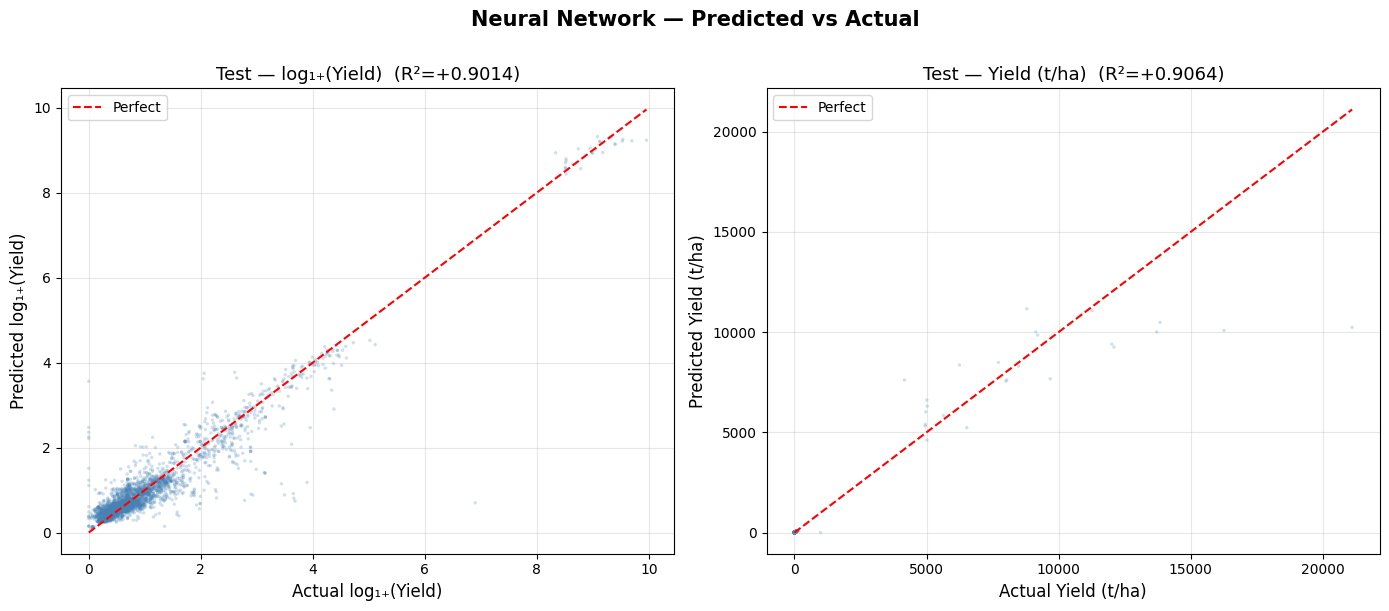

In [7]:
# ── 5a  Predicted vs Actual (log + raw)
r = results['Test']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, space in zip(axes, ['log', 'raw']):
    p = r[f'preds_{space}']
    t = r[f'trues_{space}']
    ax.scatter(t, p, alpha=0.25, s=6, c='steelblue', edgecolors='none')
    lim = [min(t.min(), p.min()), max(t.max(), p.max())]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
    label = 'log₁₊(Yield)' if space == 'log' else 'Yield (t/ha)'
    ax.set_xlabel(f'Actual {label}', fontsize=12)
    ax.set_ylabel(f'Predicted {label}', fontsize=12)
    ax.set_title(f'Test — {label}  (R²={r[f"r2_{space}"]:+.4f})', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Neural Network — Predicted vs Actual', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('nn_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

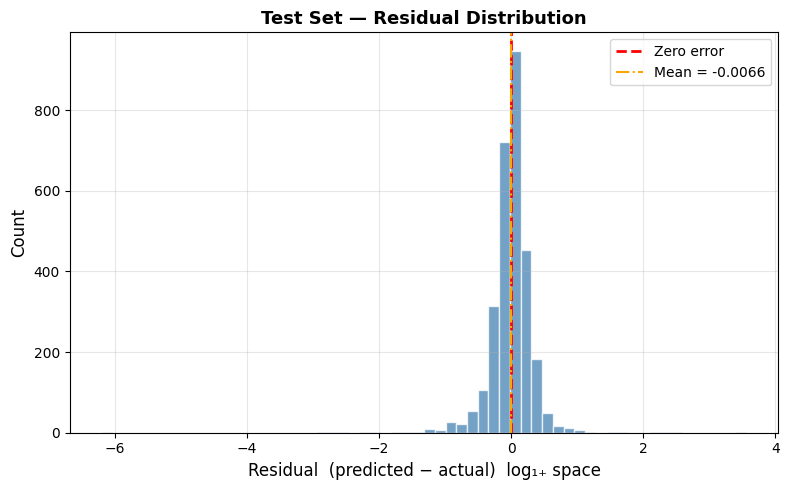

In [8]:
# ── 5b  Residual distribution (log-space)
residuals = r['preds_log'] - r['trues_log']

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=60, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(0, color='red', lw=2, linestyle='--', label='Zero error')
ax.axvline(residuals.mean(), color='orange', lw=1.5, linestyle='-.',
           label=f'Mean = {residuals.mean():.4f}')
ax.set_xlabel('Residual  (predicted − actual)  log₁₊ space', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Test Set — Residual Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('nn_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

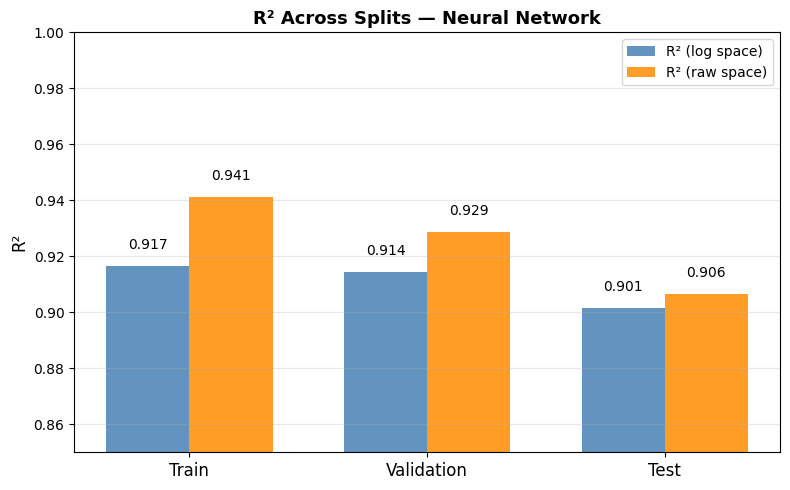

In [9]:
# ── 5c  R² comparison across splits
split_names = list(results.keys())
r2_log_vals = [results[s]['r2_log'] for s in split_names]
r2_raw_vals = [results[s]['r2_raw'] for s in split_names]

x = np.arange(len(split_names))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, r2_log_vals, w, label='R² (log space)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, r2_raw_vals, w, label='R² (raw space)', color='darkorange', alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(split_names, fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_ylim(0.85, 1.0)
ax.set_title('R² Across Splits — Neural Network', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nn_r2_bars.png', dpi=150, bbox_inches='tight')
plt.show()

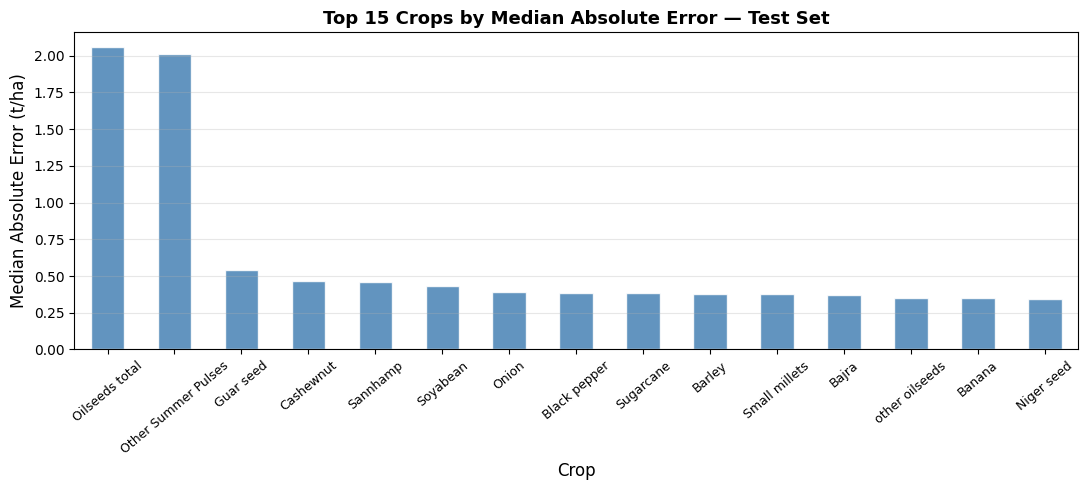

In [10]:
# ── 5d  Per-crop absolute error (test set)
test_crop = X.iloc[X_test_df.index if hasattr(X_test_df, 'index') else np.arange(len(X_test))]

# Rebuild a small analysis df from the raw df
test_mask = df.index.isin(X_test_df.index)
test_analysis = df[test_mask].copy()
test_analysis['abs_error_raw'] = np.abs(r['preds_raw'] - r['trues_raw'])

crop_err = (test_analysis.groupby('Crop')['abs_error_raw']
            .median().sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(11, 5))
crop_err.plot(kind='bar', ax=ax, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_xlabel('Crop', fontsize=12)
ax.set_ylabel('Median Absolute Error (t/ha)', fontsize=12)
ax.set_title('Top 15 Crops by Median Absolute Error — Test Set', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nn_crop_error.png', dpi=150, bbox_inches='tight')
plt.show()